In [1]:
# %pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import numpy as np
import pandas as pd

from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

RANDOM_STATE = 1

In [3]:
data = pd.read_csv('../../data/processed/data_selected.csv')

# Date를 날짜형으로 변환
data["Date"] = pd.to_datetime(data["Date"])

# 날짜순 정렬
data = data.sort_values("Date").reset_index(drop=True)

# 정렬 후 Date 제거
data = data.drop(columns=["Date"])

### Risk_Label을 통일하는 함수 정의

In [4]:
# Risk_Label을 0/1로 통일
# Low Risk / Low risk / low risk -> 0
# High Risk / High risk / high risk -> 1
# 이미 0/1이면 그대로 처리
    
def encode_risk_label(y_raw):
    
    if isinstance(y_raw, pd.DataFrame):
        y_raw = y_raw.iloc[:, 0]

    y_raw = y_raw.copy()

    if y_raw.dtype == object:
        y_key = (
            y_raw.astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r"[\s_\-]+", " ", regex=True)
        )

        y = y_key.map({
            "low risk": 0,
            "high risk": 1,
            "0": 0,
            "1": 1
        })
    else:
        y = pd.to_numeric(y_raw, errors="coerce")

    if y.isna().any():
        print("변환 실패한 라벨:")
        print(y_raw[y.isna()].unique())
        raise ValueError("Risk_Label에 0/1로 변환되지 않은 값이 있음")

    return y.astype(int).reset_index(drop=True)

### 데이터 분할

In [5]:
# train:valid:test 45:35:20
data_train = data[:int(len(data) * 0.45)].copy()
data_valid = data[int(len(data) * 0.45):int(len(data) * 0.8)].copy()
data_test = data[int(len(data) * 0.8):].copy()

# 분할 직후 Risk_Label 인코딩
data_train["Risk_Label"] = encode_risk_label(data_train["Risk_Label"]).values
data_valid["Risk_Label"] = encode_risk_label(data_valid["Risk_Label"]).values
data_test["Risk_Label"] = encode_risk_label(data_test["Risk_Label"]).values

drop_cols = ["Risk_Label"]

X_train = data_train.drop(columns=drop_cols, errors="ignore")
y_train = data_train["Risk_Label"].astype(int)

X_valid = data_valid.drop(columns=drop_cols, errors="ignore")
y_valid = data_valid["Risk_Label"].astype(int)

X_test = data_test.drop(columns=drop_cols, errors="ignore")
y_test = data_test["Risk_Label"].astype(int)

label_name_map = {0: "LowRisk", 1: "HighRisk"}

print("train/valid/test:", len(data_train), len(data_valid), len(data_test))
print("y_train class:", y_train.map(label_name_map).value_counts().to_dict())

train/valid/test: 1848 1438 822
y_train class: {'LowRisk': 1638, 'HighRisk': 210}


### Min-Max Scaling

In [6]:
scaler = MinMaxScaler().set_output(transform="pandas")

# train에만 fit하고 valid/test에는 같은 scaler 적용
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print("train/valid/test:", len(data_train), len(data_valid), len(data_test))
print("y_train class:", y_train.value_counts().sort_index().to_dict())

train/valid/test: 1848 1438 822
y_train class: {0: 1638, 1: 210}


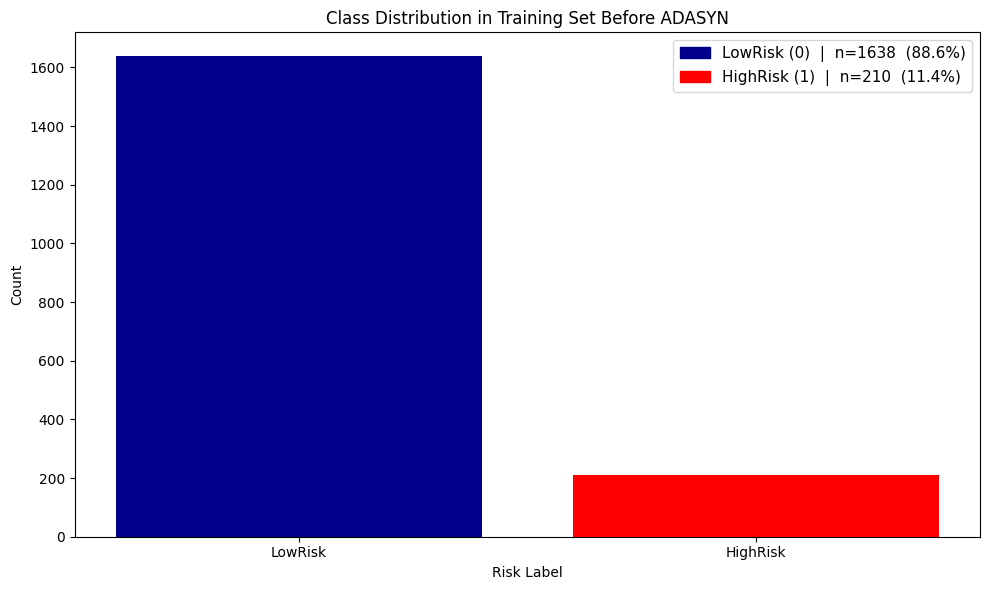

In [7]:
# 클래스 불균형 확인: train set 기준
counts = y_train.value_counts().sort_index()
label_name_map = {0: "LowRisk", 1: "HighRisk"}
colors = {0: "darkblue", 1: "red"}
total = counts.sum()

x_labels = [label_name_map.get(idx, str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(k, "grey") for k in counts.index]
)

legend_labels = [
    f"{label_name_map.get(idx, idx)} ({idx})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]

legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(idx, "grey"))
    for idx in counts.index
]

ax.legend(legend_patches, legend_labels, fontsize=11)
ax.set_xlabel("Risk Label")
ax.set_ylabel("Count")
ax.set_title("Class Distribution in Training Set Before ADASYN")
plt.tight_layout()
plt.show()

### **ADA**ptive **SYN**

### Train data에 ADASYN 적용

In [8]:
# =========================
# train 데이터에만 ADASYN 적용
# =========================

X = X_train_scaled.copy().reset_index(drop=True)
y = y_train.copy().reset_index(drop=True)

adasyn = ADASYN(
    sampling_strategy=1.0,
    n_neighbors=5,
    random_state=1
)

X_resampled, y_resampled = adasyn.fit_resample(X, y)

data_train_adasyn = X_resampled.copy().reset_index(drop=True)
data_train_adasyn["Risk_Label"] = pd.Series(y_resampled).astype(int).reset_index(drop=True)

# ADASYN 후 Signal 더미변수 반올림
dummy_cols = [
    col for col in data_train_adasyn.columns
    if col.startswith("Signal")
]

data_train_adasyn[dummy_cols] = (
    data_train_adasyn[dummy_cols]
    .round()
    .astype(int)
)

# Signal 더미변수 검증
for col in dummy_cols:
    bad_count = (~data_train_adasyn[col].isin([0, 1])).sum()
    assert bad_count == 0, f"{col}에 0/1 외 값이 남아 있음: {bad_count}개"

print("ADASYN 후 class 분포:")
print(data_train_adasyn["Risk_Label"].value_counts().sort_index())
print("✓ Signal 더미변수 0/1 반올림 완료")

ADASYN 후 class 분포:
Risk_Label
0    1638
1    1632
Name: count, dtype: int64
✓ Signal 더미변수 0/1 반올림 완료


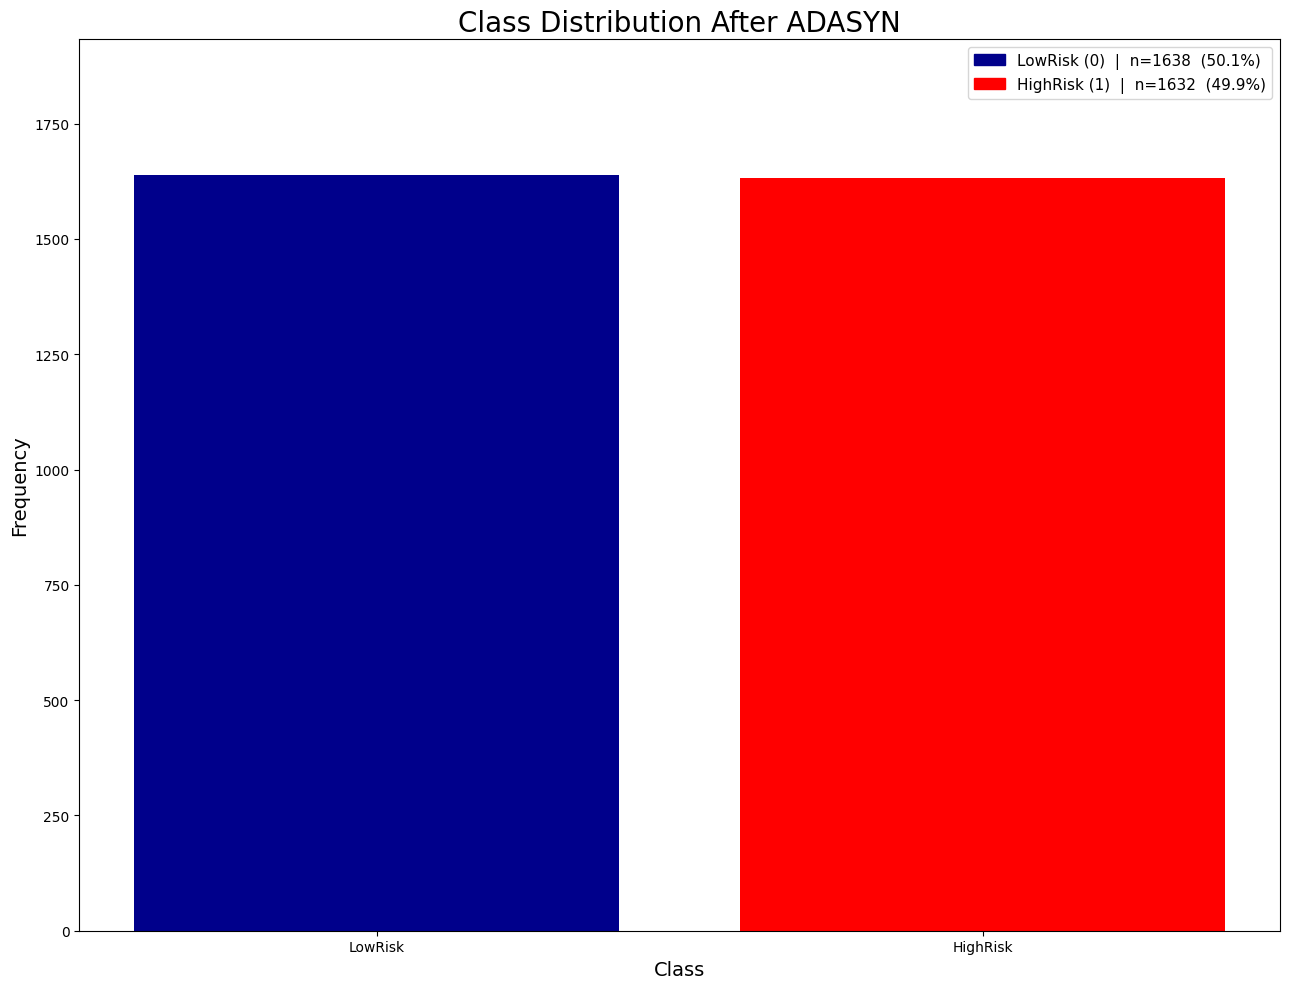

In [9]:
# 3. ADASYN 적용 후 클래스 분포 확인
counts = pd.Series(y_resampled).value_counts().sort_index()
label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
colors = {0: 'darkblue', 1: 'red'}
total = counts.sum()

x_labels = [label_name_map.get(int(idx), str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(13, 10))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(int(k), 'grey') for k in counts.index]
)

# legend에 이름, index, count, 비율 표시
legend_labels = [
    f"{label_name_map.get(int(idx), idx)} ({int(idx)})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(int(idx), 'grey'))
    for idx in counts.index
]
ax.legend(legend_patches, legend_labels, fontsize=11)

ax.set_xlabel('Class', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Class Distribution After ADASYN', fontsize=20)
plt.ylim(0, max(counts.values) * 1.18)
plt.tight_layout()
plt.show()

In [10]:
# ======= [저장 직전 최종 검증] =======

data_valid_scaled = X_valid_scaled.copy().reset_index(drop=True)
data_valid_scaled["Risk_Label"] = y_valid.reset_index(drop=True).astype(int)

data_test_scaled = X_test_scaled.copy().reset_index(drop=True)
data_test_scaled["Risk_Label"] = y_test.reset_index(drop=True).astype(int)

# 컬럼 순서 검증
assert list(data_train_adasyn.drop(columns="Risk_Label").columns) == list(data_valid_scaled.drop(columns="Risk_Label").columns)
assert list(data_train_adasyn.drop(columns="Risk_Label").columns) == list(data_test_scaled.drop(columns="Risk_Label").columns)

print("=== Risk_Label 분포 검증 ===")
print(f"[train ADASYN] {data_train_adasyn['Risk_Label'].value_counts().sort_index().to_dict()}")
print(f"[valid]        {data_valid_scaled['Risk_Label'].value_counts().sort_index().to_dict()}")
print(f"[test]         {data_test_scaled['Risk_Label'].value_counts().sort_index().to_dict()}")

for name, df in [
    ("train_adasyn", data_train_adasyn),
    ("valid", data_valid_scaled),
    ("test", data_test_scaled)
]:
    bad = set(df["Risk_Label"].unique()) - {0, 1}
    assert not bad, f"[{name}] 이상한 Risk_Label 값 발견: {bad}"

print("✓ 모든 Risk_Label 정상")
print("✓ train/valid/test 컬럼 순서 동일")

=== Risk_Label 분포 검증 ===
[train ADASYN] {0: 1638, 1: 1632}
[valid]        {0: 1256, 1: 182}
[test]         {0: 723, 1: 99}
✓ 모든 Risk_Label 정상
✓ train/valid/test 컬럼 순서 동일


In [11]:
# 5. CSV로 저장
data_train_adasyn.to_csv('../../data/processed/ADASYN/data_train_adasyn.csv', index=False)
data_valid_scaled.to_csv('../../data/processed/ADASYN/data_valid.csv', index=False)
data_test_scaled.to_csv('../../data/processed/ADASYN/data_test.csv', index=False)